# Video Analysis — 13 November 2025 (`GX010072_2025Nov13.MP4`)

Detects and quantifies blue-light pulses as contours in the Star Trails timelapse video recorded on **13 November 2025**.

**Pipeline:**
1. Set `video_name` and load/save per-video parameters from `data/config/`
2. Run `scripts/analyze_streaks.py` over all frames → `data/processed/<stem>_streaks.csv`
3. Interactively preview the top-contour frames to verify detection settings
4. Draw ROIs interactively on the best frame → `data/config/<stem>_rois.json`
5. Apply ROI assignment and a persistence filter to remove static/long-duration artifacts
6. Plot detection rates by region over clock time and save figures to `figures/`

**Key outputs** (all keyed by video stem):
- `data/processed/<stem>_streaks.csv` — raw per-frame detections
- `data/processed/<stem>_streaks_in_roi_filtered.csv` — ROI- and persistence-filtered detections
- `data/config/<stem>_analysis.json` — saved analysis parameters
- `data/config/<stem>_rois.json` — saved ROI definitions
- `figures/<stem>_detections_in_roi_*.png` — detection rate plots

> **Videos are not stored in this repository.** Run `00_download_videos_from_dryad.ipynb` to populate `video/` before executing this notebook.

In [2]:
# Set project paths — run this cell first before any other
from pathlib import Path

ROOT          = Path('..').resolve()  # repository root (this notebook lives in notebooks/)
DATA_DIR      = ROOT / 'data'
FIGURES_DIR   = ROOT / 'figures'
VIDEO_DIR     = ROOT / 'video'
SCRIPT_DIR    = ROOT / 'scripts'
CONFIG_DIR    = DATA_DIR / 'config'
PROCESSED_DIR = DATA_DIR / 'processed'

for p in [DATA_DIR, FIGURES_DIR, VIDEO_DIR, CONFIG_DIR, PROCESSED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('ROOT          =', ROOT)
print('DATA_DIR      =', DATA_DIR)
print('FIGURES_DIR   =', FIGURES_DIR)
print('VIDEO_DIR     =', VIDEO_DIR)
print('CONFIG_DIR    =', CONFIG_DIR)
print('PROCESSED_DIR =', PROCESSED_DIR)

ROOT          = /Users/oakley/Documents/GitHub/signal_respirometry
DATA_DIR      = /Users/oakley/Documents/GitHub/signal_respirometry/data
FIGURES_DIR   = /Users/oakley/Documents/GitHub/signal_respirometry/figures
VIDEO_DIR     = /Users/oakley/Documents/GitHub/signal_respirometry/video
CONFIG_DIR    = /Users/oakley/Documents/GitHub/signal_respirometry/data/config
PROCESSED_DIR = /Users/oakley/Documents/GitHub/signal_respirometry/data/processed


## Detection method

Blue-light pulses are detected by thresholding the blue channel (optionally using B − G to suppress non-blue signal), finding contours above a minimum area, and recording their centroid and bounding box per frame to CSV. Parameters (threshold, scale, blur, etc.) are saved per-video to `data/config/` as JSON so they can be reloaded without re-running interactively.

## Per-video workflow

Run the cells below **in order**:
1. Set `video_name` and `rerun_roi` (next cell)
2. Load saved parameters for this video (or accept defaults)
3. Optionally edit and save updated parameters
4. Run the contour extractor to produce the detections CSV
5. Preview top frames interactively to verify threshold/scale settings
6. Draw ROIs interactively (skipped automatically if a saved ROI JSON already exists)
7. Set `start_clock` and `moonrise_offset` for the x-axis and annotation
8. Apply ROI + persistence filter; export filtered CSV; plot detection rates
9. Run the visual overlay viewer for a final sanity check

> To force re-drawing ROIs, set `rerun_roi = True` in cell 2.

In [3]:
video_name = "GX010072_2025Nov13.MP4"

# Toggle ROI re-selection when running end-to-end
rerun_roi = False  # False = reuse existing ROI JSON if present; True = force interactive ROI selection
print('rerun_roi =', rerun_roi)

rerun_roi = False


In [4]:
# Load saved analysis parameters for the current video (or accept defaults)
import json

# List available videos in VIDEO_DIR
videos = sorted([p.name for p in VIDEO_DIR.iterdir() if p.is_file() and p.suffix.lower() in {'.mp4','.mov','.mkv','.avi','.m4v'}])
try:
    video_name
except NameError:
    video_name = videos[0] if videos else 'GX010072.MP4'

print('Current video_name =', video_name)

# Try to load saved params for this video (if present)
params_path = CONFIG_DIR / f"{Path(video_name).stem}_analysis.json"
if params_path.exists():
    with open(params_path, 'r') as f:
        saved = json.load(f)
    # Apply known params if defined in saved JSON
    analyze_scale = float(saved.get('analyze_scale', globals().get('analyze_scale', 0.5)))
    blue_thresh   = saved.get('blue_thresh', globals().get('blue_thresh', 60))
    blur_ksize    = int(saved.get('blur_ksize', globals().get('blur_ksize', 0)))
    min_area      = float(saved.get('min_area', globals().get('min_area', 1.5)))
    use_bminusg   = bool(saved.get('use_bminusg', globals().get('use_bminusg', True)))
    seconds_per_frame = float(saved.get('seconds_per_frame', globals().get('seconds_per_frame', 30.0)))
    # Persistence filter params
    enable_persistence_filter = bool(saved.get('enable_persistence_filter', globals().get('enable_persistence_filter', True)))
    persistence_link_radius_px = float(saved.get('persistence_link_radius_px', globals().get('persistence_link_radius_px', 8.0)))
    max_track_duration_s = float(saved.get('max_track_duration_s', globals().get('max_track_duration_s', 50.0)))
    print('Loaded saved parameters from', params_path)
else:
    print('No saved parameters found for this video; using current defaults.')

# Show the parameters currently in effect (using variables if set, else defaults)
effective = {
    'analyze_scale': float(globals().get('analyze_scale', 0.5)),
    'blue_thresh': globals().get('blue_thresh', 60),
    'blur_ksize': int(globals().get('blur_ksize', 0)),
    'min_area': float(globals().get('min_area', 1.5)),
    'use_bminusg': bool(globals().get('use_bminusg', True)),
    'seconds_per_frame': float(globals().get('seconds_per_frame', 30.0)),
    # Persistence filter params
    'enable_persistence_filter': bool(globals().get('enable_persistence_filter', True)),
    'persistence_link_radius_px': float(globals().get('persistence_link_radius_px', 8.0)),
    'max_track_duration_s': float(globals().get('max_track_duration_s', 50.0)),
}
print('Using parameters:', json.dumps(effective, indent=2))

Current video_name = GX010072_2025Nov13.MP4
Loaded saved parameters from /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010072_2025Nov13_analysis.json
Using parameters: {
  "analyze_scale": 0.5,
  "blue_thresh": 40,
  "blur_ksize": 0,
  "min_area": 1.5,
  "use_bminusg": true,
  "seconds_per_frame": 30.0,
  "enable_persistence_filter": true,
  "persistence_link_radius_px": 8.0,
  "max_track_duration_s": 190.0
}


In [5]:
# Save current parameters for this video (does not overwrite an existing file unless forced)
import json

# Base parameters come from currently defined globals (e.g., loaded from file) or sensible defaults
gs = globals()
base_params = {
    'analyze_scale': float(gs.get('analyze_scale', 0.5)),
    'blue_thresh': gs.get('blue_thresh', 60),  # may be None to use Otsu
    'blur_ksize': int(gs.get('blur_ksize', 0)),
    'min_area': float(gs.get('min_area', 1.5)),
    'use_bminusg': bool(gs.get('use_bminusg', True)),
    'seconds_per_frame': float(gs.get('seconds_per_frame', 30.0)),
    # Persistence filtering parameters
    'enable_persistence_filter': bool(gs.get('enable_persistence_filter', True)),
    'persistence_link_radius_px': float(gs.get('persistence_link_radius_px', 8.0)),
    'max_track_duration_s': float(gs.get('max_track_duration_s', 50.0)),
}

# Optional overrides (examples). Keep keys commented out to let JSON/default values drive parameters.
overrides = {
    # 'seconds_per_frame': 30.0,
    # 'blue_thresh': 40,           # or None for Otsu
    # 'use_bminusg': False,
    # 'analyze_scale': 0.5,
    # 'blur_ksize': 3,
    # 'min_area': 2.0,
    # 'enable_persistence_filter': True,
    # 'persistence_link_radius_px': 8.0,
    # 'max_track_duration_s': 50.0,
}

# Set to True to overwrite an existing params file
try:
    force_overwrite
except NameError:
    force_overwrite = False

allowed_keys = set(base_params.keys())
unknown = set(overrides.keys()) - allowed_keys
if unknown:
    print('Warning: ignoring unknown keys in overrides:', sorted(unknown))
    for k in sorted(unknown):
        overrides.pop(k, None)

def _coerce(key, value):
    if key == 'blue_thresh':
        return int(value) if value is not None else None
    if key in ('blur_ksize',):
        return int(value)
    if key in ('analyze_scale', 'min_area', 'seconds_per_frame', 'persistence_link_radius_px', 'max_track_duration_s'):
        return float(value)
    if key in ('use_bminusg', 'enable_persistence_filter'):
        return bool(value)
    return value

params = dict(base_params)
for k, v in overrides.items():
    params[k] = _coerce(k, v)

params_path = CONFIG_DIR / f"{Path(video_name).stem}_analysis.json"
if params_path.exists() and not force_overwrite:
    print('Parameters file already exists:', params_path)
    print('Not overwriting. Set force_overwrite=True to replace it.')
else:
    with open(params_path, 'w') as f:
        json.dump(params, f, indent=2)
    print('Saved parameters to', params_path)
    print('Parameters written:', json.dumps(params, indent=2))
    # Update globals so subsequent cells use the newly saved values immediately
    for k, v in params.items():
        globals()[k] = v

Parameters file already exists: /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010072_2025Nov13_analysis.json
Not overwriting. Set force_overwrite=True to replace it.


In [6]:
# Extract all contours across the entire video and find the best frame for ROI selection
import sys, subprocess, io
import pandas as pd

# Fall back to defaults if parameters were not loaded from config
try: analyze_scale
except NameError: analyze_scale = 0.5       # detection scale; coordinates saved at this scale
try: blue_thresh
except NameError: blue_thresh = 60          # fixed threshold; set to None to use Otsu
try: blur_ksize
except NameError: blur_ksize = 0            # odd kernel size (3, 5, 7), or 0 to disable
try: min_area
except NameError: min_area = 1.5            # minimum contour area (at scaled resolution)
try: use_bminusg
except NameError: use_bminusg = True        # use B-G channel to suppress non-blue signal
try: seconds_per_frame
except NameError: seconds_per_frame = 30.0  # real-world seconds per frame (Star Trails interval)

# Paths
an_script  = SCRIPT_DIR / 'analyze_streaks.py'
video_path = VIDEO_DIR / video_name
mask_path  = PROCESSED_DIR / f"{video_path.stem}_hotmask.png"
csv_path   = PROCESSED_DIR / f"{video_path.stem}_streaks.csv"

if not an_script.exists():
    raise FileNotFoundError(f"Analyzer script not found: {an_script}")
if not video_path.exists():
    raise FileNotFoundError(f"Video not found: {video_path}")

# Run analyzer over the entire video
cmd = [
    sys.executable,
    str(an_script),
    '--video', str(video_path),
    '--output', str(csv_path),
    '--scale', str(analyze_scale),
    '--blur-ksize', str(blur_ksize),
    '--min-area', str(min_area),
    '--seconds-per-frame', str(seconds_per_frame),
]
if use_bminusg:
    cmd += ['--use-bminusg']
if blue_thresh is not None:
    cmd += ['--blue-thresh', str(int(blue_thresh))]
if mask_path.exists():
    cmd += ['--mask-in', str(mask_path)]
print('Command:', ' '.join(cmd))
ret = subprocess.run(cmd, capture_output=True, text=True)
print(ret.stdout)
if ret.stderr:
    print('stderr:\n', ret.stderr)
print('Wrote detections to:', csv_path)

# Load CSV (skip metadata preamble) and compute best frame (most detections)
with open(csv_path, 'r') as f:
    lines = f.readlines()
header_idx = 0
for i, line in enumerate(lines[:100]):
    if line.lower().startswith('frame,'):
        header_idx = i
        break

df = pd.read_csv(io.StringIO(''.join(lines[header_idx:])))
per_frame = df.groupby('frame').size().rename('count').reset_index()
if len(per_frame) == 0:
    raise RuntimeError('No detections found; check threshold/scale settings.')

best_row = per_frame.loc[per_frame['count'].idxmax()]
best_frame_index = int(best_row['frame'])
best_count = int(best_row['count'])
print(f'Best frame for ROI selection: frame {best_frame_index} with {best_count} contours')

Command: /opt/homebrew/Caskroom/miniforge/base/envs/walle/bin/python /Users/oakley/Documents/GitHub/signal_respirometry/scripts/analyze_streaks.py --video /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010072_2025Nov13.MP4 --output /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010072_2025Nov13_streaks.csv --scale 0.5 --blur-ksize 0 --min-area 1.5 --seconds-per-frame 30.0 --use-bminusg --blue-thresh 40
Done. Wrote detections to /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010072_2025Nov13_streaks.csv

Wrote detections to: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010072_2025Nov13_streaks.csv
Best frame for ROI selection: frame 162 with 12 contours


In [7]:
# Preview the top-N frames with most contours and overlay detections (interactive)
# Controls: SPACE/RIGHT next frame, LEFT prev, Q/ESC quit
import sys, subprocess

top_n = 10          # number of top frames to cycle through
line_thickness = 5  # contour line width; increase for small contours

csv_path      = PROCESSED_DIR / f"{Path(video_name).stem}_streaks.csv"
viewer_script = SCRIPT_DIR / 'preview_top_contours.py'

cmd = [
    sys.executable,
    str(viewer_script),
    '--video', str(VIDEO_DIR / video_name),
    '--csv', str(csv_path),
    '--scale', str(analyze_scale),
    '--blur-ksize', str(blur_ksize),
    '--min-area', str(min_area),
    '--top-n', str(top_n),
    '--line-thickness', str(line_thickness),
]
if use_bminusg:
    cmd += ['--use-bminusg']
if blue_thresh is not None:
    cmd += ['--blue-thresh', str(int(blue_thresh))]
if (PROCESSED_DIR / f"{Path(video_name).stem}_hotmask.png").exists():
    cmd += ['--mask-in', str(PROCESSED_DIR / f"{Path(video_name).stem}_hotmask.png")]
print('Command:', ' '.join(cmd))
ret = subprocess.run(cmd)
print('Exit code:', ret.returncode)

Command: /opt/homebrew/Caskroom/miniforge/base/envs/walle/bin/python /Users/oakley/Documents/GitHub/signal_respirometry/scripts/preview_top_contours.py --video /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010072_2025Nov13.MP4 --csv /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010072_2025Nov13_streaks.csv --scale 0.5 --blur-ksize 0 --min-area 1.5 --top-n 10 --line-thickness 5 --use-bminusg --blue-thresh 40
Exit code: 0


In [9]:
# Define ROIs interactively on the best-contour frame
# Draw rectangular regions over the areas of interest, then press ENTER to confirm.
# Skipped automatically if a saved ROI JSON already exists; set rerun_roi = True to re-draw.
import sys, subprocess, json

try:
    frame_index = int(best_frame_index)  # set by the extraction cell
except NameError:
    frame_index = 0

scale_for_selection = 0.5  # display scale (ROI coordinates are saved in original pixels)

roi_script    = SCRIPT_DIR / "define_rois.py"
video_path    = VIDEO_DIR / video_name
roi_json_path = CONFIG_DIR / f"{video_path.stem}_rois.json"
overlay_png   = FIGURES_DIR / f"{video_path.stem}_rois_overlay.png"

try:
    rerun = bool(rerun_roi)
except NameError:
    rerun = False

print("Using video for ROI:", video_path)
print("ROI JSON target:", roi_json_path)

if (not rerun) and roi_json_path.exists():
    print("Skipping ROI definition: existing ROI JSON found at", roi_json_path)
    print("Set rerun_roi = True to re-draw ROIs interactively.")
    if overlay_png.exists():
        print("Overlay preview:", overlay_png)
else:
    cmd = [
        sys.executable,
        str(roi_script),
        "--video", str(video_path),
        "--frame-index", str(frame_index),
        "--scale", str(scale_for_selection),
        "--output", str(roi_json_path),
        "--preview", str(overlay_png),
    ]
    print("Command:", " ".join(cmd))
    ret = subprocess.run(cmd, capture_output=True, text=True)
    print(ret.stdout)
    if ret.stderr:
        print("stderr:\n", ret.stderr)
    print("ROI JSON:", roi_json_path)
    print("Overlay preview (if created):", overlay_png)

Using video for ROI: /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010072_2025Nov13.MP4
ROI JSON target: /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010072_2025Nov13_rois.json
Skipping ROI definition: existing ROI JSON found at /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010072_2025Nov13_rois.json
Set rerun_roi = True to re-draw ROIs interactively.


In [10]:
# Adjustable clock start for plotting
# Set as 'HH:MM' or 'HH:MM:SS' and rerun this cell before the plotting cell.
start_clock = '19:00'
print('start_clock =', start_clock)

# Moonrise time offset from start_clock for plotting
# Set as 'H:MM' or 'HH:MM'. Default '0:00' plots moonrise at the start.
moonrise_offset = '7:01'
print('moonrise_offset =', moonrise_offset)

start_clock = 19:00
moonrise_offset = 7:01


## ROI Mapping and Filtered Export

This step loads detections, applies the persistence filter, maps detections to ROIs, and writes the filtered in-ROI CSV used downstream.

Note: persistence-threshold diagnostics are kept in notebook 01; see that notebook for threshold exploration plots.

In [11]:
# Apply ROI and persistence filtering, then write filtered detections CSV
import io, json
import pandas as pd
import numpy as np

# Inputs
csv_path      = PROCESSED_DIR / f'{Path(video_name).stem}_streaks.csv'
roi_json_path = CONFIG_DIR / f'{Path(video_name).stem}_rois.json'

# Sanity checks for required inputs
if not csv_path.exists():
    raise FileNotFoundError(f"Detections CSV not found: {csv_path}. Run the extraction cell first.")
if not roi_json_path.exists():
    available = sorted(p.name for p in CONFIG_DIR.glob('*_rois.json'))
    msg = [
        f"ROI JSON not found for {Path(video_name).stem} at {roi_json_path}.",
        "- Did you run the ROI selection cell and press ENTER to confirm?",
        f"- Expected filename: {Path(video_name).stem}_rois.json",
        f"- Available ROI files in {CONFIG_DIR}: {available if available else 'None found'}",
        "- If you want to reuse a different video's ROI, copy it to this stem or set video_name accordingly.",
    ]
    raise FileNotFoundError("\n".join(msg))

# Load detections (skip preamble)
with open(csv_path, 'r') as f:
    lines = f.readlines()
# find data header
header_idx = 0
for i, line in enumerate(lines[:100]):
    if line.lower().startswith('frame,'):
        header_idx = i
        break

df = pd.read_csv(io.StringIO(''.join(lines[header_idx:])))
print(f"Raw detections loaded: {len(df)} rows")

# Optional: filter persistent (long-lasting) contours BEFORE ROI mapping
try:
    enable_persistence_filter
except NameError:
    enable_persistence_filter = True
try:
    persistence_link_radius_px
except NameError:
    persistence_link_radius_px = 8.0   # link detections across consecutive frames within this pixel radius (scaled coords)
try:
    max_track_duration_s
except NameError:
    max_track_duration_s = 50.0       # drop tracks lasting longer than this many seconds

if enable_persistence_filter and not df.empty:
    print(f"Persistence filter ENABLED (radius={persistence_link_radius_px}, max_duration={max_track_duration_s}s)")
    df = df.sort_values(['frame']).reset_index(drop=True).copy()
    track_id_counter = -1
    assignments = np.full(len(df), -1, dtype=int)
    active = {}  # track_id -> {'last_cx','last_cy','last_frame','start_time','end_time','length'}
    frames = df['frame'].values
    times = df['time_s'].values
    cxs = df['cx'].values.astype(float)
    cys = df['cy'].values.astype(float)
    unique_frames = np.unique(frames)
    prev_frame = None
    for f in unique_frames:
        # close any track that skipped a frame
        if prev_frame is not None and f > prev_frame + 1:
            to_close = [tid for tid, t in active.items() if t['last_frame'] < f - 1]
            for tid in to_close:
                active.pop(tid, None)
        prev_frame = f
        idxs = np.where(frames == f)[0]
        used_tids = set()
        for i in idxs:
            cx, cy = cxs[i], cys[i]
            # candidates are active tracks updated on frame f-1 and within radius
            cand = []
            for tid, t in active.items():
                if t['last_frame'] == f - 1:
                    dx = cx - t['last_cx']
                    dy = cy - t['last_cy']
                    if (dx*dx + dy*dy) <= (persistence_link_radius_px * persistence_link_radius_px) and tid not in used_tids:
                        cand.append((tid, dx*dx + dy*dy))
            if cand:
                tid = min(cand, key=lambda x: x[1])[0]
                assignments[i] = tid
                t = active[tid]
                t['last_cx'] = cx; t['last_cy'] = cy; t['last_frame'] = f; t['end_time'] = times[i]; t['length'] += 1
                used_tids.add(tid)
            else:
                track_id_counter += 1
                tid = track_id_counter
                assignments[i] = tid
                active[tid] = {'last_cx': cx, 'last_cy': cy, 'last_frame': f, 'start_time': times[i], 'end_time': times[i], 'length': 1}
    # compute durations (seconds) per track
    df['track_id'] = assignments
    agg = df.groupby('track_id').agg(start_time=('time_s','min'), end_time=('time_s','max'), length=('frame','count')).reset_index()
    agg['duration_s'] = agg['end_time'] - agg['start_time']
    drop_ids = set(agg.loc[agg['duration_s'] > max_track_duration_s, 'track_id'].astype(int).tolist())
    if drop_ids:
        before = len(df)
        df = df[~df['track_id'].isin(drop_ids)].copy()
        after = len(df)
        print(f"Persistence filter: dropped {before-after} detections from {len(drop_ids)} long-lasting tracks (>{max_track_duration_s:.1f}s)")
    else:
        print("Persistence filter: no long-lasting tracks to drop.")
else:
    print("Persistence filter DISABLED")

# Determine detection coordinate scale: prefer CSV preamble, fallback to current analyze_scale/global
meta_vals = lines[1].strip().split(',') if len(lines) > 1 else []
scale_from_preamble = float(meta_vals[3]) if len(meta_vals) >= 4 else None
scale_from_global = float(globals().get('analyze_scale', 1.0))
scale_used = scale_from_preamble if scale_from_preamble is not None else scale_from_global
if scale_from_preamble is not None and 'analyze_scale' in globals():
    try:
        if abs(scale_from_preamble - float(analyze_scale)) > 1e-6:
            print(f"Warning: CSV preamble scale ({scale_from_preamble}) differs from current analyze_scale ({float(analyze_scale)}). Using preamble scale for ROI mapping.")
    except Exception:
        pass
print(f"ROI mapping scale = {scale_used} (source={'preamble' if scale_from_preamble is not None else 'global'})")

# Load ROI JSON (rects in original pixels)
with open(roi_json_path, 'r') as f:
    roi_cfg = json.load(f)
rects = roi_cfg['rects']

# Scale ROIs to detection coordinate space (scaled by scale_used)
scaled_rects = []
for r in rects:
    scaled_rects.append({
        'label': r['label'],
        'x': int(round(r['x'] * scale_used)),
        'y': int(round(r['y'] * scale_used)),
        'w': int(round(r['w'] * scale_used)),
        'h': int(round(r['h'] * scale_used)),
    })

# Assign region per detection
labels = []
for _, row in df.iterrows():
    cx, cy = float(row['cx']), float(row['cy'])
    lab = 'outside'
    for r in scaled_rects:
        if (cx >= r['x'] and cx < r['x'] + r['w'] and cy >= r['y'] and cy < r['y'] + r['h']):
            lab = r['label']
            break
    labels.append(lab)

df['region'] = labels

# Exclude 'outside' from totals and plots
df_in = df[df['region'] != 'outside'].copy()
print(f"Detections in ROI (post-filter if enabled): {len(df_in)}")

# Write filtered detections (persistence-filtered and in-ROI only) to a new CSV for downstream use
filtered_csv_path = PROCESSED_DIR / f"{Path(video_name).stem}_streaks_in_roi_filtered.csv"
# Only write the viewer-required columns, in the original order, and include the original preamble for scale
required_cols = ['frame','time_s','region','cx','cy','area','bbox_x','bbox_y','bbox_w','bbox_h']
missing_cols = [c for c in required_cols if c not in df_in.columns]
if missing_cols:
    raise ValueError(f"Filtered DataFrame missing required columns: {missing_cols}")
df_out = df_in[required_cols].copy()
# Write preamble from the raw CSV so viewers can parse scale
with open(filtered_csv_path, 'w') as out_f:
    out_f.writelines(lines[:header_idx+1])  # includes metadata lines + header row
# Append data without header to keep the original header intact
df_out.to_csv(filtered_csv_path, index=False, header=False, mode='a')
print('Wrote filtered in-ROI detections to', filtered_csv_path)

Raw detections loaded: 6133 rows
Persistence filter ENABLED (radius=8.0, max_duration=190.0s)
Persistence filter: dropped 5436 detections from 87 long-lasting tracks (>190.0s)
ROI mapping scale = 0.5 (source=preamble)
Detections in ROI (post-filter if enabled): 336
Wrote filtered in-ROI detections to /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010072_2025Nov13_streaks_in_roi_filtered.csv


## Detection-Rate Plots (HH:MM Axis)

This step uses the filtered in-ROI detections from the prior cell and renders time-series plots with HH:MM clock labels.

Totals per region (in-ROI only):
 region
middle    236
right      63
left       37
dtype: int64
Saved figure to /Users/oakley/Documents/GitHub/signal_respirometry/figures/GX010072_2025Nov13_detections_in_roi_1s.png


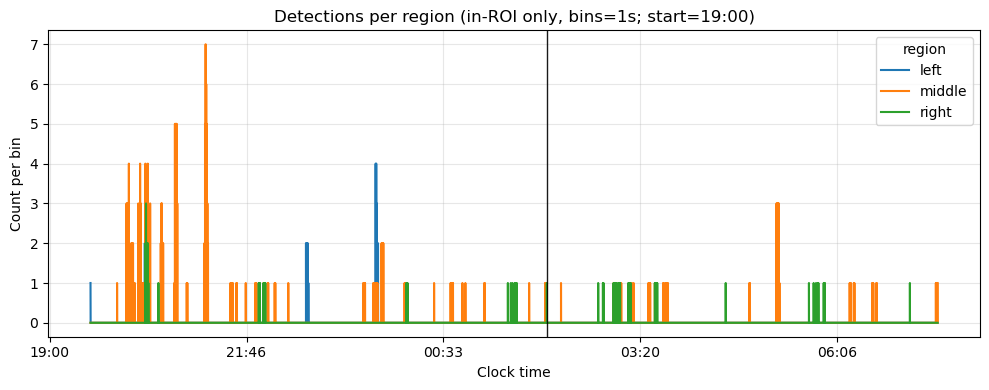

Saved figure to /Users/oakley/Documents/GitHub/signal_respirometry/figures/GX010072_2025Nov13_detections_in_roi_60s.png


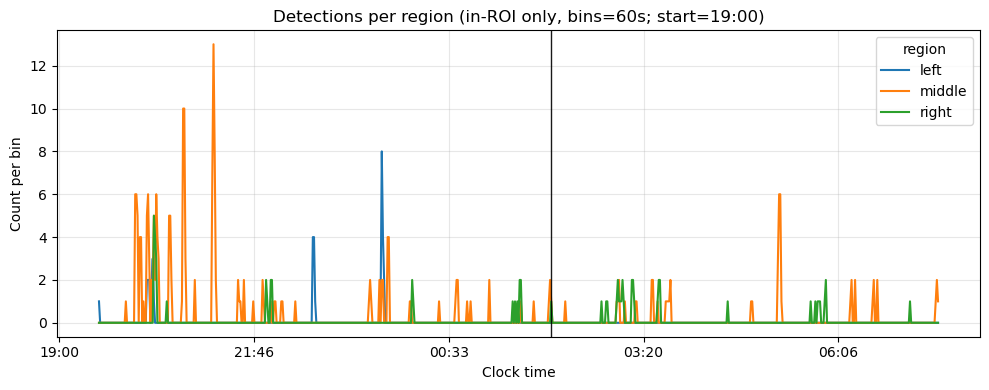

In [12]:
# Plot rates by region using HH:MM clock labels
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker as mticker

# Adjustable clock start: set as HH:MM or HH:MM:SS (e.g., '19:00', '19:15', '19:00:30')
try:
    start_clock
except NameError:
    start_clock = '19:00'

def hhmm_formatter(x, pos):
    total_seconds = float(x) + _start_offset
    hours = int((total_seconds // 3600) % 24)
    minutes = int((total_seconds % 3600) // 60)
    return f"{hours:02d}:{minutes:02d}"

def _parse_start_clock(s: str) -> int:
    parts = s.split(':')
    if len(parts) < 2:
        raise ValueError("start_clock must be 'HH:MM' or 'HH:MM:SS'")
    h = int(parts[0]) % 24
    m = int(parts[1])
    sec = int(parts[2]) if len(parts) > 2 else 0
    return h * 3600 + m * 60 + sec

_start_offset = _parse_start_clock(start_clock)

# Moonrise offset relative to start_clock, formatted as 'H:MM' or 'HH:MM' (e.g., '0:00', '0:45', '1:30')
try:
    moonrise_offset
except NameError:
    moonrise_offset = '0:00'

def _parse_hhmm_offset(s: str) -> int:
    parts = s.split(':')
    if len(parts) < 2:
        raise ValueError("moonrise_offset must be 'H:MM' or 'HH:MM'")
    h = int(parts[0])
    m = int(parts[1])
    return h * 3600 + m * 60

_moonrise_x = _parse_hhmm_offset(moonrise_offset)

if df_in.empty:
    print("No in-ROI detections to plot.")
else:
    # Totals per region (in-ROI only)
    region_totals = df_in.groupby('region').size().sort_values(ascending=False)
    print('Totals per region (in-ROI only):\n', region_totals)

    # Plot bin counts at 1s and 60s (in-ROI only) with HH:MM x-axis
    for bin_seconds in (1.0, 60.0):
        dfb = df_in.copy()
        dfb['time_bin'] = (dfb['time_s'] // bin_seconds) * bin_seconds
        counts = dfb.groupby(['region', 'time_bin']).size().reset_index(name='count')
        pivot = counts.pivot(index='time_bin', columns='region', values='count').fillna(0)
        # Build a complete time index so missing bins are zero, not absent
        if not dfb.empty:
            start_bin = float(dfb['time_bin'].min())
            end_bin = float(dfb['time_bin'].max())
            all_bins = np.arange(start_bin, end_bin + bin_seconds, bin_seconds, dtype=float)
            pivot = pivot.reindex(all_bins, fill_value=0)
        fig, ax = plt.subplots(figsize=(10, 4))
        pivot.plot(ax=ax)
        # Thin black vertical line at moonrise (relative to start)
        ax.axvline(_moonrise_x, color='k', linewidth=1.0, alpha=0.9)
        ax.set_title(f'Detections per region (in-ROI only, bins={bin_seconds:.0f}s; start={start_clock})')
        ax.set_xlabel('Clock time')
        ax.set_ylabel('Count per bin')
        # Format x-axis ticks as HH:MM based on seconds since start
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(hhmm_formatter))
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        # Save figure with video stem in figures directory
        out_path = FIGURES_DIR / f"{Path(video_name).stem}_detections_in_roi_{int(bin_seconds)}s.png"
        plt.savefig(out_path, dpi=200)
        print('Saved figure to', out_path)
        plt.show()

In [13]:
# Final visual check: overlay ONLY in-ROI detections on the video (yellow)
# with labels of which LOI they are in
import sys, subprocess

# Prefer the filtered in-ROI, persistence-filtered CSV if available
filtered_csv = PROCESSED_DIR / f"{Path(video_name).stem}_streaks_in_roi_filtered.csv"
raw_csv      = PROCESSED_DIR / f"{Path(video_name).stem}_streaks.csv"
csv_path     = filtered_csv if filtered_csv.exists() else raw_csv

roi_json_path = CONFIG_DIR / f"{Path(video_name).stem}_rois.json"
viewer_script = SCRIPT_DIR / 'preview_contours_with_roi.py'

# Viewer options
line_thickness = 5
show_roi_edges = True   # draw ROI rectangles for context
start_frame    = 0      # change to focus on a specific segment

# Determine the correct detection/display scale for the viewer
scale_for_viewer = None
try:
    scale_for_viewer = float(analyze_scale)
except NameError:
    scale_for_viewer = None
if scale_for_viewer is None:
    # Parse from CSV preamble (filtered now includes preamble; fallback to raw CSV if needed)
    import io
    try:
        with open(csv_path, 'r') as f:
            _lines = f.readlines()
        if len(_lines) > 1:
            _vals = _lines[1].strip().split(',')
            if len(_vals) >= 4:
                scale_for_viewer = float(_vals[3])
    except Exception:
        scale_for_viewer = None
if scale_for_viewer is None:
    # Last resort
    scale_for_viewer = 1.0

cmd = [
    sys.executable,
    str(viewer_script),
    '--video', str(VIDEO_DIR / video_name),
    '--csv', str(csv_path),
    '--roi-config', str(roi_json_path),
    '--line-thickness', str(line_thickness),
    '--scale', str(scale_for_viewer),
]

if show_roi_edges:
    cmd += ['--show-roi']

print('Using CSV:', csv_path)
print('Scale for viewer:', scale_for_viewer)
print('Command:', ' '.join(cmd))
print('Controls: SPACE play/pause, LEFT/RIGHT step, R toggle ROI, Q/ESC quit')
ret = subprocess.run(cmd)
print('Exit code:', ret.returncode)

Using CSV: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010072_2025Nov13_streaks_in_roi_filtered.csv
Scale for viewer: 0.5
Command: /opt/homebrew/Caskroom/miniforge/base/envs/walle/bin/python /Users/oakley/Documents/GitHub/signal_respirometry/scripts/preview_contours_with_roi.py --video /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010072_2025Nov13.MP4 --csv /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010072_2025Nov13_streaks_in_roi_filtered.csv --roi-config /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010072_2025Nov13_rois.json --line-thickness 5 --scale 0.5 --show-roi
Controls: SPACE play/pause, LEFT/RIGHT step, R toggle ROI, Q/ESC quit
Exit code: 0
